# Grid2Op Introduction

This notebook provides a **backend-centric explanation of [Grid2Op](https://github.com/rte-france/Grid2Op)** — a framework for simulating electrical grid environments.

We will focus on the following:
- Backend role in simulation
- Observation and action system
- Power flow simulation
- Demonstration with backends like `PandaPower`

In [1]:
# 📦 Install required packages (uncomment if not installed)
# !pip install grid2op[lightsim] matplotlib numpy

## 1. What is Grid2Op?

**Grid2Op** is an open-source Python framework that simulates electrical grid operations. It is primarily used for:
- Reinforcement learning (RL) environments
- Stress-testing agent-based grid control
- Simulating grid behavior under various contingencies

**Core Concepts:**
- `Environment`: The simulation sandbox
- `Backend`: Power flow simulator
- `Observation`: What the agent sees
- `Action`: What the agent can do

In [3]:
from grid2op import make
from grid2op.Backend import PandaPowerBackend
import numpy as np
import matplotlib.pyplot as plt

## 2. Backend Overview

In Grid2Op, the **backend is responsible for computing the power flow**, simulating the consequences of actions taken by the agent.

### Backend Responsibilities
- Solve AC or DC power flow
- Enforce grid constraints (thermal limits, voltage, etc.)
- Provide the state transition function `f(state, action)`

### Available Backends
- `PandaPowerBackend`
- `LightSimBackend` (fast, sparse matrix-based)
- `PyPowerBackend`

In [6]:
# Create an environment with LightSimBackend
env = make("l2rpn_case14_sandbox", backend=PandaPowerBackend(with_numba=False))
obs = env.reset()
env.backend

## 3. Observation Object (Backend Output)

The **`Observation` object** reflects the current state of the grid.

Example attributes:
- `obs.rho`: Thermal loading on lines
- `obs.load_p`, `obs.load_q`: Active/reactive power demand
- `obs.gen_p`, `obs.gen_q`: Generation output
- `obs.topo_vect`: Bus/branch topology

In [9]:
print("Rho (line loading):", obs.rho[:5])
print("Generator active power:", obs.gen_p[:5])

Rho (line loading): [0.34012985 0.36042336 0.2721007  0.26722595 0.82812935]
Generator active power: [81.4 79.3  5.3  0.   0. ]


## 4. Taking an Action (Backend Simulation)

Grid2Op uses **Action objects** to modify the state.
The backend computes the resulting grid state based on physical laws.

Example actions:
- Change generator dispatch
- Change topology (bus switching)
- Line disconnections

Let's do a no-op action (i.e., take no action):

In [10]:
action = env.action_space()  # No action (default)
next_obs, reward, done, info = env.step(action)
print("Reward:", reward)
print("Next state line loading:", next_obs.rho[:5])

Reward: 64.98741
Next state line loading: [0.32674646 0.35659143 0.26395932 0.2672041  0.82961446]


## 5. Backend Visualization

Let’s visualize how power line loading changes after disconnection:

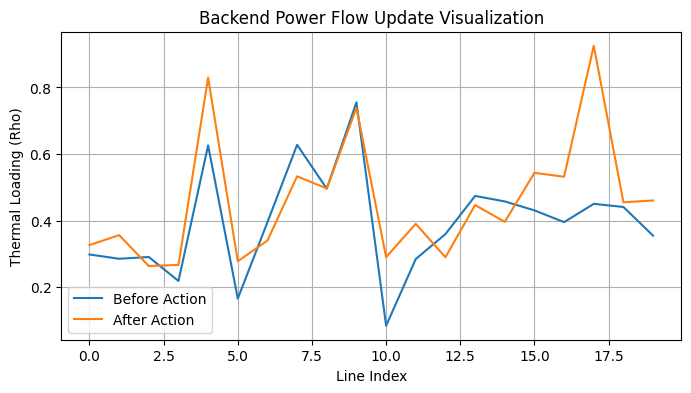

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(obs.rho, label="Before Action")
plt.plot(next_obs.rho, label="After Action")
plt.xlabel("Line Index")
plt.ylabel("Thermal Loading (Rho)")
plt.legend()
plt.title("Backend Power Flow Update Visualization")
plt.grid(True)
plt.show()

## 6. Write a Simple Rule-Based Agent

This agent will disconnect a line if its `rho > 0.95`.

In [17]:
env.reset()
for step in range(5):
    obs = env.get_obs()
    action = env.action_space()
    high_load_lines = np.where(obs.rho > 0.95)[0]
    for line_id in high_load_lines:
        action.set_line_status(line_id=int(line_id), new_status=False)
    obs, reward, done, _ = env.step(action)
    print(f"Step {step}, Reward: {reward}, Done: {done}")
    if done:
        break

TypeError: 'numpy.ndarray' object is not callable

## Summary

- `Backend` handles the physics of power flow
- Actions are validated and resolved via the backend
- Observations are the result of backend computations

Next steps:
- Integrating GridPACK backend
- Train RL agents (DQN, PPO) using this backend